In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Building Blocks of Decision Trees
A **decision tree** is a hierarchical data structure composed of nodes organised in a tree-like topology, where each node represents either a decision point or a terminal prediction. This structure facilitates interpretable classification by simulating a sequence of conditional rules derived from the training data.

Nodes in a decision tree fall into three categories:
- **Root node**: The uppermost node with no parent, initiating the tree by posing a question on a selected feature, which branches into two child nodes based on the response.
- **Internal node**: A node with exactly one parent, posing a further question on another (or the same) feature, leading to two child nodes. These nodes refine the partitioning of the data space.
- **Leaf node**: A terminal node with one parent and no children, where a class prediction is made based on the majority class of instances reaching that node.

The hierarchy ensures that paths from the root to leaves define unique decision rules, enabling the tree to handle multi-class problems, though binary splits are standard for simplicity and computational efficiency.

## Recursive Learning Process
Classification-tree learning proceeds via **recursive partitioning**, starting from the root and growing the tree depth-wise until stopping conditions are met. At each node, the algorithm evaluates potential splits to maximise purity in child nodes.

The core mechanism involves:
1. Selecting a **feature** $f$ from the available set.
2. Choosing a **split point** $sp$ within the range of values for $f$.
3. Partitioning the node's data into left and right subsets based on whether instances satisfy $f \leq sp$ (for continuous features) or match categorical conditions.

The optimal split is the one maximising **information gain** (IG), computed as:
$$
IG(f, sp) = I(\text{parent}) - \left( \frac{N_{\text{left}}}{N} I(\text{left}) + \frac{N_{\text{right}}}{N} I(\text{right}) \right),
$$
where:
- $I(\cdot)$ is the impurity criterion for a node,
- $N$ is the total number of samples at the parent node,
- $N_{\text{left}}$ and $N_{\text{right}}$ are the sample counts in the child nodes.

If $IG = 0$ (no reduction in impurity), the node is declared a leaf, as further splitting yields no benefit. Otherwise, the process recurses on the child nodes.

This greedy approach—selecting the locally optimal split at each step—ensures efficiency but may not yield a globally optimal tree. Recursion halts based on hyperparameters like maximum depth, minimum samples per split, or minimum IG threshold, preventing overfitting by limiting tree complexity.

For categorical features, splits evaluate subsets of categories; for continuous, they sort values and test midpoints between unique observations to find the best $sp$.

## Impurity Criteria
Impurity measures quantify node heterogeneity, guiding splits towards homogeneous children. Two primary criteria are implemented in libraries like scikit-learn:

- **Gini impurity** (or Gini index):
  $$
  I(\text{node}) = 1 - \sum_{k=1}^{K} p_k^2,
  $$
  where $p_k$ is the proportion of class $k$ instances in the node, and $K$ is the number of classes. Gini favours splits creating one dominant class, ranging from 0 (pure) to $1 - 1/K$ (maximum impurity).

- **Entropy** (from information theory):
  $$
  I(\text{node}) = - \sum_{k=1}^{K} p_k \log_2 p_k,
  $$
  with entropy zero for pure nodes and maximised at uniform distributions. It penalises impurity logarithmically, often leading to slightly deeper trees than Gini but similar performance.

Gini is computationally lighter (no logarithms) and the default in many implementations. Both encourage balanced splits implicitly through weighted averaging in IG.

In practice, the choice between criteria has minimal impact on accuracy for most datasets, but entropy may perform better in scenarios with many classes due to its sensitivity to probabilistic distributions.

## Implementation in Scikit-Learn
Scikit-learn's `DecisionTreeClassifier` encapsulates the learning process, allowing specification of the impurity criterion via the `criterion` parameter ('gini' or 'entropy').

A self-contained example demonstrates the workflow:

In [ ]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Generate a synthetic binary classification dataset
X, y = make_classification(
	n_samples=1000, n_features=10, n_informative=5, n_classes=2, random_state=1
)

# Split into training and test sets (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=1
)

# Instantiate classifier with Gini criterion
classifier = DecisionTreeClassifier(criterion="gini", random_state=1)

# Fit to training data
classifier.fit(X_train, y_train)

# Predict on test set
y_pred = classifier.predict(X_test)

# Evaluate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {test_accuracy:.4f}")

Test set accuracy: 0.8500


Here, `make_classification` creates agnostic data for reproducibility. Stratification ensures balanced classes in splits. The `random_state` fixes randomness in tree construction.

To visualise the tree:

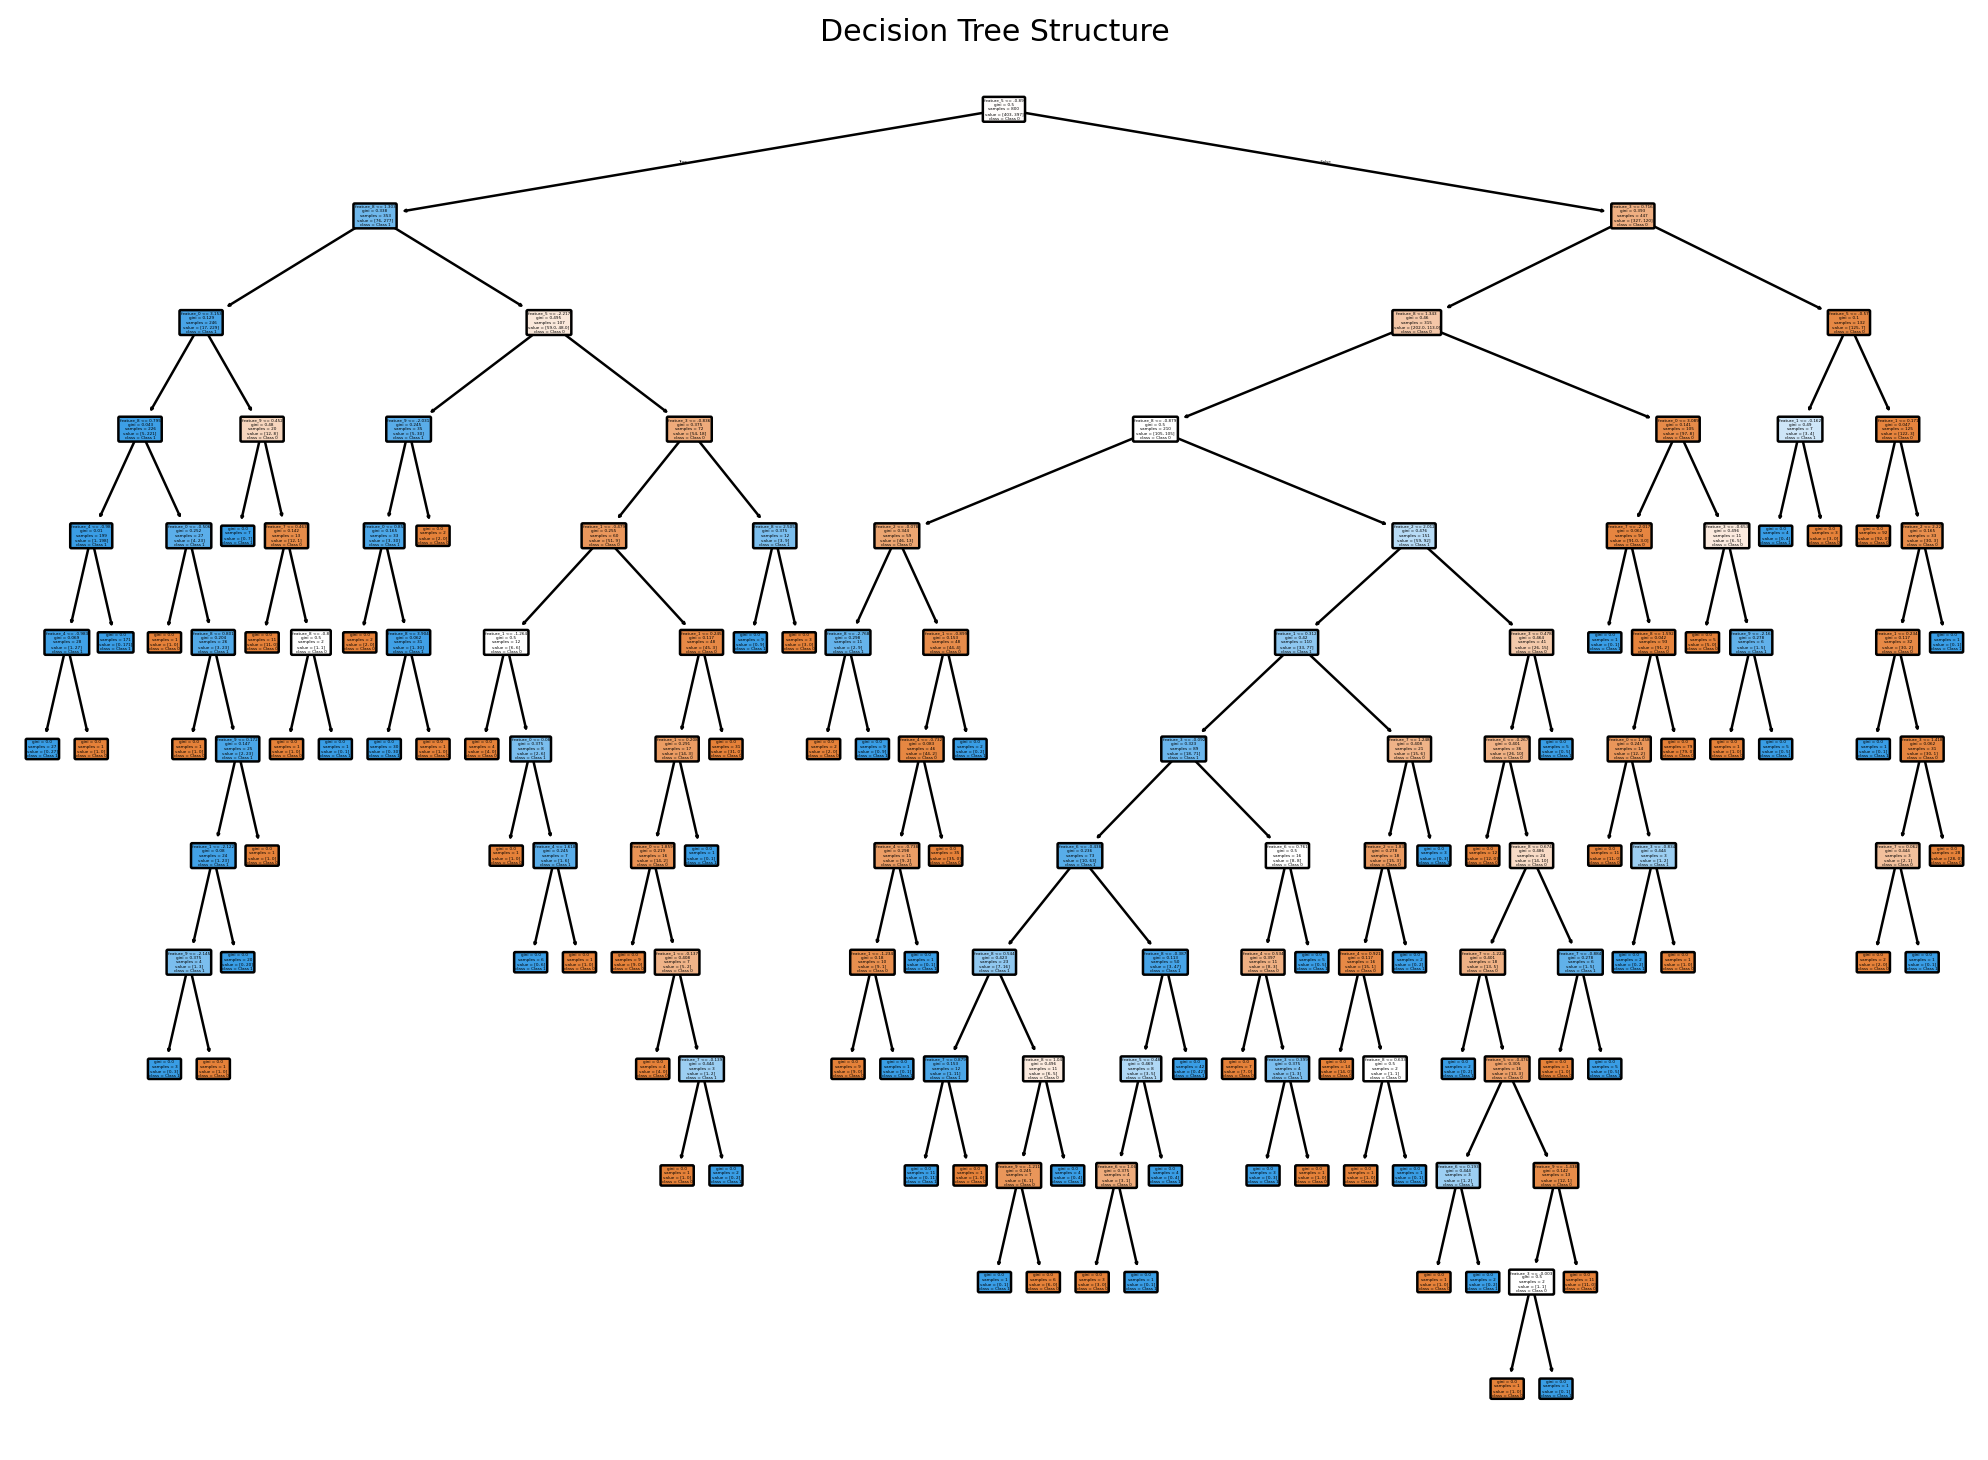

In [ ]:
from sklearn.tree import plot_tree

# Plot the decision tree
fig, ax = plt.subplots(figsize=(14, 10), dpi=180)
plot_tree(
	classifier,
	feature_names=[f"feature_{i}" for i in range(X.shape[1])],
	class_names=["Class 0", "Class 1"],
	filled=True,
	rounded=True,
	ax=ax,
)
ax.set_title("Decision Tree Structure")
plt.show()

This renders nodes with split details, sample counts, and Gini values, illustrating the hierarchy.

## Visualising Information Gain
To pedagogically demonstrate IG, consider a node visualisation. The following code uses Matplotlib (as Seaborn lacks direct tree plotting) to recreate a simple IG diagram:

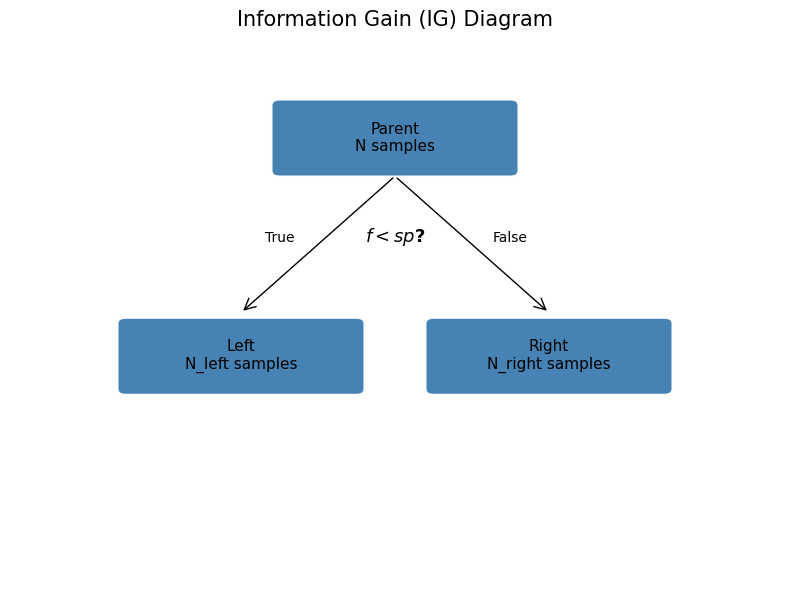

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()

# Node positions and sizes
nodes = {
	"parent": (0.35, 0.75, 0.3, 0.12),
	"left": (0.15, 0.35, 0.3, 0.12),
	"right": (0.55, 0.35, 0.3, 0.12),
}

# Draw nodes
for node, (x, y, w, h) in nodes.items():
	box = FancyBboxPatch(
		(x, y),
		w,
		h,
		boxstyle="round,pad=0.01",
		edgecolor="white",
		facecolor="steelblue",
	)
	ax.add_patch(box)

# Draw arrows
ax.add_patch(
	FancyArrowPatch(
		(0.5, 0.74), (0.3, 0.49), arrowstyle="->", mutation_scale=20, lw=1.0
	)
)
ax.add_patch(
	FancyArrowPatch(
		(0.5, 0.74), (0.7, 0.49), arrowstyle="->", mutation_scale=20, lw=1.0
	)
)

# Labels
ax.text(0.5, 0.81, "Parent\nN samples", ha="center", va="center", fontsize=11)
ax.text(0.3, 0.41, "Left\nN_left samples", ha="center", va="center", fontsize=11)
ax.text(0.7, 0.41, "Right\nN_right samples", ha="center", va="center", fontsize=11)
ax.text(0.5, 0.62, r"$f < sp$?", ha="center", fontsize=13, fontweight="bold")
ax.text(0.35, 0.62, "True", ha="center", fontsize=10)
ax.text(0.65, 0.62, "False", ha="center", fontsize=10)

ax.set_title("Information Gain (IG) Diagram", fontsize=15)
plt.tight_layout()
plt.show()

This diagram emphasises the split structure underlying IG computation.

## Practical Considerations and Extensions
Unconstrained trees risk overfitting by memorising training data, leading to poor generalisation. Hyperparameters like `max_depth`, `min_samples_split`, and `min_impurity_decrease` control growth.

For enhanced performance, ensemble methods build upon single trees: random forests average multiple decorrelated trees, while boosting sequentially corrects errors.

Theoretically, decision trees are universal approximators for discrete functions, but their bias-variance trade-off necessitates tuning. In high dimensions, feature selection via IG implicitly combats the curse of dimensionality by prioritising informative variables.